In [29]:
# ==============================================================
# CELL 1 – Imports, Hardware Setup & Drive Mount
# ==============================================================
import sys, os, random
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

# Set Global Seed for total reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device}')
print(f'PyTorch version: {torch.__version__}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device in use: cuda
PyTorch version: 2.10.0+cu128


In [30]:
import numpy as np

# 1. Path of the processed .npz file
PATH_NPZ = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/IBD_1000pt_FingerPrint.npz'

print(f'Loading processed data from {PATH_NPZ}...')

data = np.load(PATH_NPZ)
print("Variables found in the .npz:", list(data.keys()))

# Estrazione diretta sapendo le chiavi esatte
X_data = data['spectra'].astype(np.float32)
Y_data = data['labels'].flatten().astype(np.int64)

# Fix shape if needed (now for 1000 points)
if X_data.shape[0] == 1000 and X_data.shape[1] == len(Y_data):
    X_data = X_data.T

N, L = X_data.shape
print("-" * 40)
print(f'Usable spectra : {N}')
print(f'Spectral points: {L}')
print(f'HC (0)         : {(Y_data==0).sum()}')
print(f'IBD (1)        : {(Y_data==1).sum()}')
print(f'X shape        : {X_data.shape}')
print(f'Y shape        : {Y_data.shape}')


Loading processed data from /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/IBD_1000pt_FingerPrint.npz...
Variables found in the .npz: ['spectra', 'wavelengths', 'labels', 'groups']
----------------------------------------
Usable spectra : 228
Spectral points: 1000
HC (0)         : 93
IBD (1)        : 135
X shape        : (228, 1000)
Y shape        : (228,)


In [31]:
# ==============================================================
# CELL 3 – Import SpectraMAENet & Load Foundation Weights
# ==============================================================
import subprocess
import sys
import os
import torch

REPO_PATH  = '/content/SpectraMAENet'
MODEL_PATH = os.path.join(REPO_PATH, 'model')

if not os.path.exists(REPO_PATH):
    print("Cloning SpectraMAENet repository...")
    subprocess.run(['git', 'clone', 'https://github.com/pengjuRen99/SpectraMAENet.git', REPO_PATH], check=True)

init_file = os.path.join(MODEL_PATH, '__init__.py')
if not os.path.exists(init_file):
    open(init_file, 'w').close()

for p in [REPO_PATH, MODEL_PATH]:
    if p in sys.path: sys.path.remove(p)
sys.path.insert(0, REPO_PATH)

from model.Spectra_MAE import MaskedAutoencoderViT

# --- Hyperparameters (MANDATORY: Must match Pre-Training perfectly!) ---
SPECTRA_SIZE   = 1000
PATCH_SIZE     = 100
ENCODER_DIM    = 256
ENCODER_DEPTH  = 8
ENCODER_HEADS  = 8
DIM_MLP        = 512   # 2 * ENCODER_DIM
DECODER_DIM    = 128
DECODER_DEPTH  = 2 # Changed from 2 to 1 to match expected pre-trained model architecture
DECODER_HEADS  = 8  # CORRECT: 8 heads!

def build_smae_encoder():
    """Builds the MAE Architecture."""
    return MaskedAutoencoderViT(
        spectra_size      = SPECTRA_SIZE,
        patch_size        = PATCH_SIZE,
        encoder_dim       = ENCODER_DIM,
        depth             = ENCODER_DEPTH,
        num_heads         = ENCODER_HEADS,
        dim_mlp           = DIM_MLP,
        decoder_embed_dim = DECODER_DIM,
        decoder_depth     = DECODER_DEPTH,
        decoder_num_heads = DECODER_HEADS,
        norm_pix_loss     = False,
    ).to(device)

# CHANGE THIS to point to the .pth file generated by your Pre-Training Notebook
PATH_PRETRAINED = '/content/drive/MyDrive/Tesi_Raman/Models/PreTrain/SMAE/1000_pt/FingerPrint/Min-Max/exp_7/smae_pretrained_model.pth'

print("Loading pre-trained Foundation Model...")
foundation_model = build_smae_encoder()
foundation_model.load_state_dict(torch.load(PATH_PRETRAINED, map_location=device))
foundation_model.eval()

print(f'✅ Foundation Model loaded successfully from: {PATH_PRETRAINED}')


Loading pre-trained Foundation Model...
✅ Foundation Model loaded successfully from: /content/drive/MyDrive/Tesi_Raman/Models/PreTrain/SMAE/1000_pt/FingerPrint/Min-Max/exp_7/smae_pretrained_model.pth


In [32]:
# ==============================================================
# CELL 4 – Classification Model Architecture (Encoder + Head)
# ==============================================================
import torch.nn as nn



class SMAEClassifier(nn.Module):
    """
    Takes the pre-trained SMAE Encoder and attaches an MLP Classification Head.
    Includes methods to freeze/unfreeze the encoder for the LP-FT strategy.
    """
    def __init__(self, smae_model, encoder_dim, n_classes=2, head_hidden_dim=128):
        super().__init__()
        # Extract only the encoder from the MAE
        self.encoder = smae_model

        # Build the MLP Classification Head
        self.head = nn.Sequential(
            nn.LayerNorm(encoder_dim),
            nn.Linear(encoder_dim, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(head_hidden_dim, n_classes)
        )

        # Custom initialization of head weights (e.g., He Normal)
        self._init_weights()

    def _init_weights(self):
        """Initializes the linear layers of the head using Kaiming (He) Normal."""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                # Kaiming normal is ideal for ReLU/GELU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Forward pass through the MAE encoder (mask_ratio=0.0 because we want the full spectrum)
        latent, _, _ = self.encoder.forward_encoder(x, mask_ratio=0.0)

        # Average pooling over the patch tokens (excluding the CLS token at index 0)
        emb = latent[:, 1:, :].mean(dim=1)   # Shape: (Batch_Size, encoder_dim)

        # Pass features through the classification head
        logits = self.head(emb)
        return logits

    def freeze_encoder(self):
        """Freezes the encoder weights for Stage 1: Linear Probing."""
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.head.parameters():
            param.requires_grad = True

    def unfreeze_encoder(self):
        """Unfreezes the encoder weights for Stage 2: Full Fine-Tuning."""
        for param in self.parameters():
            param.requires_grad = True


In [33]:
# ==============================================================
# CELL 5 – Train / Val / Test Split (70-15-15)
# ==============================================================
from sklearn.model_selection import train_test_split

# ---> CHANGE THIS VALUE TO TRY DIFFERENT SPLITS <---
SEED = 42 # Try 0, 123, 999, or None for a different split each time

# Splitting Data into 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data, Y_data, test_size=0.30, random_state=SEED, stratify=Y_data
)

# Splitting Temp into 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples (HC: {(y_train==0).sum()}, IBD: {(y_train==1).sum()})")
print(f"Val set:   {X_val.shape[0]} samples (HC: {(y_val==0).sum()}, IBD: {(y_val==1).sum()})")
print(f"Test set:  {X_test.shape[0]} samples (HC: {(y_test==0).sum()}, IBD: {(y_test==1).sum()})")


Train set: 159 samples (HC: 65, IBD: 94)
Val set:   34 samples (HC: 14, IBD: 20)
Test set:  35 samples (HC: 14, IBD: 21)


In [34]:
# ==============================================================
# CELL 6 – LP-FT FINE-TUNING (Train / Val)
# ==============================================================
import time
import random
import torch
import copy
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import numpy as np

# Hyperparameters
LP_EPOCHS = 100
FT_EPOCHS = 100
LP_LR = 1e-3
FT_LR = 1e-5
BATCH_SIZE = 32
PATIENCE = 30
HEAD_DIM = 256

def eval_model(model, loader):
    model.eval()
    preds, labels, probs, losses = [], [], [], []
    criterion = torch.nn.CrossEntropyLoss()
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            probs.append(F.softmax(logits, dim=1)[:, 1].cpu())
            preds.append(logits.argmax(dim=1).cpu())
            labels.append(yb.cpu())
    return (
        torch.cat(preds).numpy(),
        torch.cat(labels).numpy(),
        torch.cat(probs).numpy(),
        np.mean(losses)
    )

# --- CUSTOM DATASET FOR ADVANCED RAMAN DATA AUGMENTATION ---
class RamanAugmentedDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_val = self.X[idx].clone()
        if self.augment:
            # 1. Random intensity multiplier (+/- 5%)
            scale = random.uniform(0.95, 1.05)
            x_val = x_val * scale
            # 2. Very light Gaussian noise to simulate instrumental noise
            noise = torch.randn_like(x_val) * 1e-4
            x_val = x_val + noise



        return x_val, self.y[idx]

# Base data
Xtr = torch.from_numpy(X_train).unsqueeze(1)
ytr = torch.from_numpy(y_train)
Xva = torch.from_numpy(X_val).unsqueeze(1)
yva = torch.from_numpy(y_val)

# DataLoaders with Augmentation ONLY on the Train Set
train_dataset = RamanAugmentedDataset(Xtr, ytr, augment=True)
val_dataset = RamanAugmentedDataset(Xva, yva, augment=False)

loader_tr = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
loader_va = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model setup (Uses HEAD_DIM automatically from the default in cell 4)
model = SMAEClassifier(copy.deepcopy(foundation_model), ENCODER_DIM, n_classes=2).to(device)

# Class weights
n_sano = (ytr == 0).sum().item()
n_ibd = (ytr == 1).sum().item()
weights = torch.tensor([1.0/n_sano if n_sano>0 else 0, 1.0/n_ibd if n_ibd>0 else 0], device=device)
weights = weights / weights.sum() * 2.0

criterion = torch.nn.CrossEntropyLoss(weight=weights)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": [], "lr": []}

# --- STAGE 1: LP ---
print("STAGE 1: Linear Probing")
model.freeze_encoder()
optimizer_lp = AdamW(model.head.parameters(), lr=LP_LR)
scheduler_lp = ReduceLROnPlateau(optimizer_lp, mode='min', factor=0.5, patience=8)

for epoch in range(LP_EPOCHS):
    model.train()
    total_loss = 0
    all_preds_tr = []
    all_labels_tr = []
    for Xb, yb in loader_tr:
        optimizer_lp.zero_grad()
        logits = model(Xb.to(device))
        loss = criterion(logits, yb.to(device))
        loss.backward()
        optimizer_lp.step()
        total_loss += loss.item()
        all_preds_tr.append(logits.argmax(dim=1).detach().cpu())
        all_labels_tr.append(yb.detach().cpu())

    train_preds = torch.cat(all_preds_tr).numpy()
    train_labels = torch.cat(all_labels_tr).numpy()
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_acc = accuracy_score(labels_val, preds_val)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    # Step scheduler WITH val_loss
    scheduler_lp.step(val_loss)

    train_loss_epoch = total_loss/len(loader_tr)
    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["lr"].append(optimizer_lp.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[LP] Epoch {epoch+1:02d}/{LP_EPOCHS} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

# --- STAGE 2: FT ---
print("\nSTAGE 2: Fine-Tuning")
model.unfreeze_encoder()
optimizer_ft = AdamW(model.parameters(), lr=FT_LR)
scheduler_ft = ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=5)

best_f1 = 0.0
best_loss = float('inf')
no_improve = 0
best_state = None

for epoch in range(FT_EPOCHS):
    model.train()
    total_loss = 0
    all_preds_tr = []
    all_labels_tr = []
    for Xb, yb in loader_tr:
        optimizer_ft.zero_grad()
        logits = model(Xb.to(device))
        loss = criterion(logits, yb.to(device))
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()
        all_preds_tr.append(logits.argmax(dim=1).detach().cpu())
        all_labels_tr.append(yb.detach().cpu())

    train_preds = torch.cat(all_preds_tr).numpy()
    train_labels = torch.cat(all_labels_tr).numpy()
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    preds_val, labels_val, probs_val, val_loss = eval_model(model, loader_va)
    val_acc = accuracy_score(labels_val, preds_val)
    val_f1 = f1_score(labels_val, preds_val, average="macro")

    # Step scheduler WITH val_loss
    scheduler_ft.step(val_loss)

    train_loss_epoch = total_loss/len(loader_tr)
    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["lr"].append(optimizer_ft.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[FT] Epoch {epoch+1:02d}/{FT_EPOCHS} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

    # 1. Save the best model based on F1 Score
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    elif val_f1 == best_f1 and val_loss < best_loss: # Break ties with loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # 2. Early stopping based on Validation Loss
    if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (No improvement in Val Loss)")
            break

model.load_state_dict(best_state)
print("\nTraining Completed. Best Val F1:", best_f1, "| Best Val Loss:", best_loss)

STAGE 1: Linear Probing
[LP] Epoch 01/100 | Train Loss: 8.1744 | Val Loss: 6.5914 | Train F1: 0.4770 | Val F1: 0.2917
[LP] Epoch 10/100 | Train Loss: 3.2871 | Val Loss: 0.8913 | Train F1: 0.4843 | Val F1: 0.2917
[LP] Epoch 20/100 | Train Loss: 1.4980 | Val Loss: 1.9482 | Train F1: 0.5064 | Val F1: 0.2917
[LP] Epoch 30/100 | Train Loss: 0.8643 | Val Loss: 0.6096 | Train F1: 0.5505 | Val F1: 0.7786
[LP] Epoch 40/100 | Train Loss: 0.7789 | Val Loss: 0.9578 | Train F1: 0.5094 | Val F1: 0.2917
[LP] Epoch 50/100 | Train Loss: 0.8623 | Val Loss: 0.4861 | Train F1: 0.3746 | Val F1: 0.4440
[LP] Epoch 60/100 | Train Loss: 0.6205 | Val Loss: 0.5624 | Train F1: 0.6409 | Val F1: 0.7589
[LP] Epoch 70/100 | Train Loss: 0.6540 | Val Loss: 0.5930 | Train F1: 0.5841 | Val F1: 0.8464
[LP] Epoch 80/100 | Train Loss: 0.6378 | Val Loss: 0.5650 | Train F1: 0.6905 | Val F1: 0.8068
[LP] Epoch 90/100 | Train Loss: 0.6405 | Val Loss: 0.5708 | Train F1: 0.6378 | Val F1: 0.8068
[LP] Epoch 100/100 | Train Loss: 0.6

In [35]:
# ============================================================
# CELL 7 — Test Set Evaluation
# ============================================================
Xte = torch.from_numpy(X_test).unsqueeze(1)
yte = torch.from_numpy(y_test)
loader_te = DataLoader(TensorDataset(Xte, yte), batch_size=BATCH_SIZE, shuffle=False)

preds_test, labels_test, probs_test, test_loss = eval_model(model, loader_te)

print("Test Accuracy:", accuracy_score(labels_test, preds_test))
print("Test Macro-F1:", f1_score(labels_test, preds_test, average="macro"))
print("Test ROC-AUC:", roc_auc_score(labels_test, probs_test) if len(np.unique(labels_test)) > 1 else "N/A")


Test Accuracy: 0.8857142857142857
Test Macro-F1: 0.8833333333333333
Test ROC-AUC: 0.9489795918367347


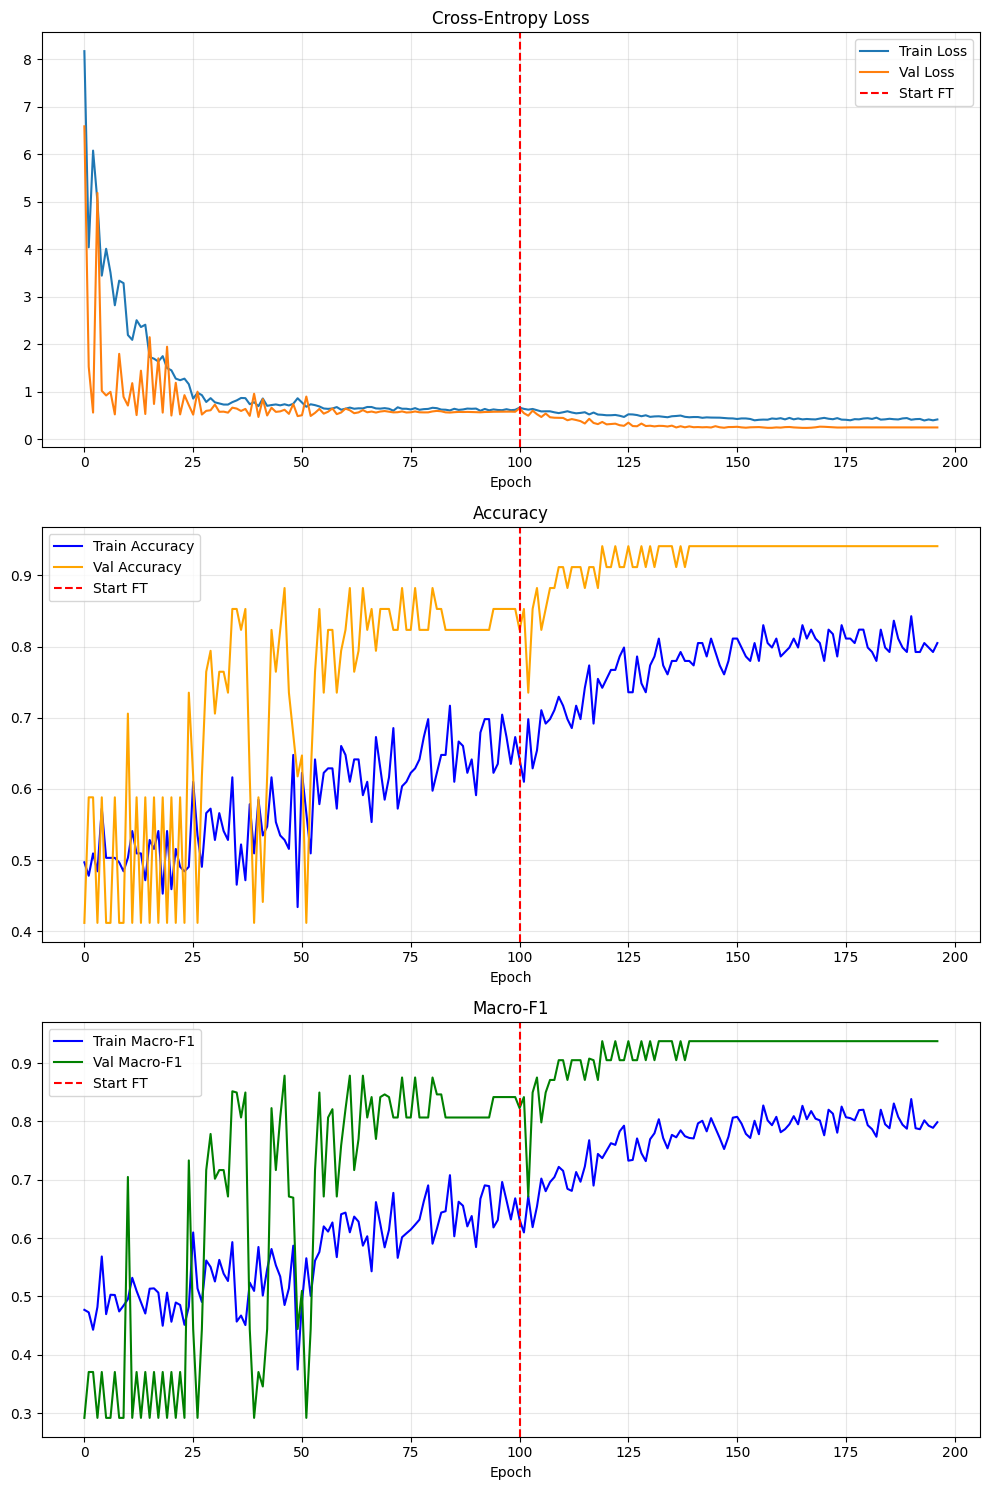

In [36]:
# ============================================================
# CELL 8 — Training Curves
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# --- Loss ---
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[0].set_title("Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy ---
axes[1].plot(history["train_acc"], label="Train Accuracy", color='blue')
axes[1].plot(history["val_acc"], label="Val Accuracy", color='orange')
axes[1].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- F1 Score ---
axes[2].plot(history["train_f1"], label="Train Macro-F1", color='blue')
axes[2].plot(history["val_f1"], label="Val Macro-F1", color='green')
axes[2].axvline(LP_EPOCHS, color='r', linestyle='--', label='Start FT')
axes[2].set_title("Macro-F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

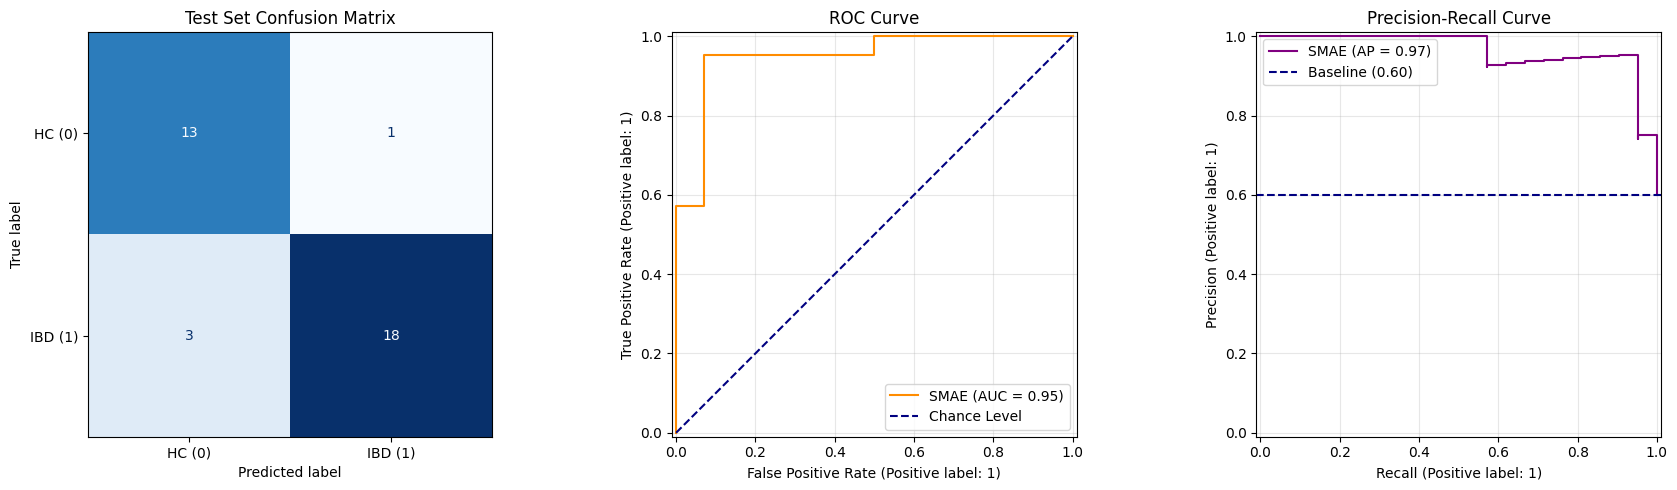


 GLOBAL CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      HC (0)       0.81      0.93      0.87        14
     IBD (1)       0.95      0.86      0.90        21

    accuracy                           0.89        35
   macro avg       0.88      0.89      0.88        35
weighted avg       0.89      0.89      0.89        35



In [37]:
# ============================================================
# CELL 9 — Clinical Evaluation & Scientific Plotting
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay,
                             PrecisionRecallDisplay)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(labels_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC (0)', 'IBD (1)'])
disp.plot(cmap='Blues', ax=ax1, colorbar=False)
ax1.set_title("Test Set Confusion Matrix")

# 2. ROC Curve
RocCurveDisplay.from_predictions(labels_test, probs_test, ax=ax2, color='darkorange', name='SMAE')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Chance Level')
ax2.set_title("ROC Curve")
ax2.grid(alpha=0.3)
ax2.legend()

# 3. PR Curve
PrecisionRecallDisplay.from_predictions(labels_test, probs_test, ax=ax3, color='purple', name='SMAE')
baseline = sum(labels_test) / len(labels_test)
ax3.axhline(baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax3.set_title("Precision-Recall Curve")
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

print('\n' + '='*50)
print(' GLOBAL CLASSIFICATION REPORT (Test Set)')
print('='*50)
print(classification_report(labels_test, preds_test, target_names=['HC (0)', 'IBD (1)']))


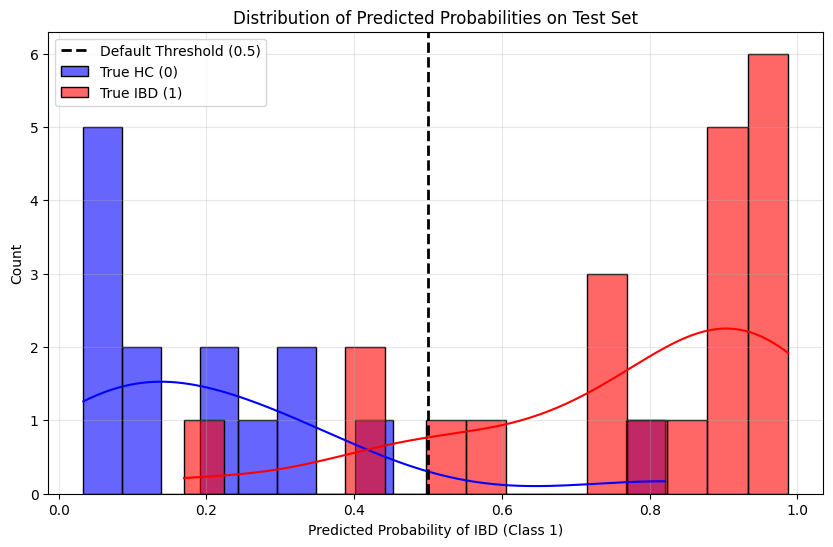

In [38]:
# ============================================================
# CELL 10 — Prediction Distribution (Histogram)
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(probs_test[labels_test == 0], bins=15, color='blue', alpha=0.6, label='True HC (0)', kde=True)
sns.histplot(probs_test[labels_test == 1], bins=15, color='red', alpha=0.6, label='True IBD (1)', kde=True)
plt.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities on Test Set')
plt.xlabel('Predicted Probability of IBD (Class 1)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [39]:
# ============================================================
# CELL 12 — Caricamento asse X (Raman Shift)
# ============================================================
import numpy as np

# Load the x-axis (Raman shift) from the .npz file
data = np.load(PATH_NPZ)

# Usiamo direttamente la chiave 'wavelengths'
x_axis = data['wavelengths'].flatten()
print("Asse X (Raman Shift) caricato correttamente dalla chiave 'wavelengths'.")
print(f"Range: {x_axis.min():.2f} - {x_axis.max():.2f} cm⁻¹")


Asse X (Raman Shift) caricato correttamente dalla chiave 'wavelengths'.
Range: 650.00 - 1750.00 cm⁻¹


### 📊 Valutazione K-Fold delle metriche sul Test Set
Alleniamo il modello 5 volte su fold diversi del set di training/validation unito (85% dei dati). Ad ogni fold, calcoliamo le metriche direttamente sul **Test Set isolato (15%)**. Alla fine, calcoliamo la **media e la deviazione standard** delle metriche sul Test Set per valutare la stabilità del modello al variare dei dati di addestramento.

In [40]:
# ============================================================
# CELL 13 — K-Fold: Media delle metriche sul Test Set
# ============================================================
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
import copy

# RIPRISTINIAMO IL SEED QUI PER GARANTIRE LA RIPRODUCIBILITÀ ESATTA
# ANCHE SE LA CELLA VIENE ESEGUITA PIU' VOLTE!
set_seed(42)

print("Preparazione dati per K-Fold...")
# Uniamo Train e Val attuali (85% dei dati totali)
X_cv = np.concatenate((X_train, X_val), axis=0)
y_cv = np.concatenate((y_train, y_val), axis=0)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Liste per salvare le metriche del Test Set valutate in ogni fold
test_accuracies = []
test_f1s = []
test_aucs = []

# Parametri Training IDENTICI al singolo split
K_LP_EPOCHS = 100
K_FT_EPOCHS = 100
K_BATCH_SIZE = 32
PATIENCE = 30

# Prepariamo subito il Test Set in tensori
Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)
yte_t = y_test

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- Inizio FOLD {fold+1}/{N_SPLITS} ---")

    X_tr_f, y_tr_f = X_cv[train_idx], y_cv[train_idx]
    X_va_f, y_va_f = X_cv[val_idx], y_cv[val_idx]

    # Conversione in tensori
    Xtr_t = torch.from_numpy(X_tr_f).unsqueeze(1)
    ytr_t = torch.from_numpy(y_tr_f)
    Xva_t = torch.from_numpy(X_va_f).unsqueeze(1)
    yva_t = torch.from_numpy(y_va_f)

    # Datasets
    train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
    val_ds   = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

    loader_tr = DataLoader(train_ds, batch_size=K_BATCH_SIZE, shuffle=True)
    loader_va = DataLoader(val_ds, batch_size=K_BATCH_SIZE, shuffle=False)

    # Inizializza Modello
    model_f = SMAEClassifier(copy.deepcopy(foundation_model), ENCODER_DIM, n_classes=2).to(device)

    # Pesi bilanciati
    n_s = (y_tr_f == 0).sum()
    n_i = (y_tr_f == 1).sum()
    pesi = [1.0/n_s if n_s>0 else 0, 1.0/n_i if n_i>0 else 0]
    w_t = torch.tensor(pesi, dtype=torch.float32, device=device)
    w_t = w_t / w_t.sum() * 2.0
    criterion_f = torch.nn.CrossEntropyLoss(weight=w_t)

    # ==================================================
    # STAGE 1: Linear Probing
    # ==================================================
    print("  -> STAGE 1: Linear Probing")
    model_f.freeze_encoder()
    opt_lp = AdamW(model_f.head.parameters(), lr=1e-3)
    sch_lp = ReduceLROnPlateau(opt_lp, mode='min', factor=0.5, patience=8)
    for ep in range(K_LP_EPOCHS):
        model_f.train()
        tot_loss = 0
        for Xb, yb in loader_tr:
            opt_lp.zero_grad()
            loss = criterion_f(model_f(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_lp.step()
            tot_loss += loss.item()

        _, _, _, v_loss = eval_model(model_f, loader_va)
        sch_lp.step(v_loss)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"     [LP] Epoch {ep+1:02d}/{K_LP_EPOCHS} | Train Loss: {tot_loss/len(loader_tr):.4f} | Val Loss: {v_loss:.4f}")

    # ==================================================
    # STAGE 2: Fine Tuning
    # ==================================================
    print("  -> STAGE 2: Fine-Tuning")
    model_f.unfreeze_encoder()
    opt_ft = AdamW(model_f.parameters(), lr=1e-5)
    sch_ft = ReduceLROnPlateau(opt_ft, mode='min', factor=0.5, patience=5)

    best_loss = float('inf')
    best_f1 = 0.0
    best_state = None
    no_imp = 0

    for ep in range(K_FT_EPOCHS):
        model_f.train()
        tot_loss = 0
        for Xb, yb in loader_tr:
            opt_ft.zero_grad()
            loss = criterion_f(model_f(Xb.to(device)), yb.to(device))
            loss.backward()
            opt_ft.step()
            tot_loss += loss.item()

        preds_va, labels_va, _, v_loss = eval_model(model_f, loader_va)
        v_f1 = f1_score(labels_va, preds_va, average="macro")
        sch_ft.step(v_loss)

        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"     [FT] Epoch {ep+1:02d}/{K_FT_EPOCHS} | Train Loss: {tot_loss/len(loader_tr):.4f} | Val Loss: {v_loss:.4f} | Val F1: {v_f1:.4f}")

        # Salvataggio basato su F1 (come singolo split)
        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = {k: v.clone() for k, v in model_f.state_dict().items()}
        elif v_f1 == best_f1 and v_loss < best_loss:
            best_state = {k: v.clone() for k, v in model_f.state_dict().items()}

        if v_loss < best_loss:
            best_loss = v_loss
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                print(f"     [!] Early stopping at epoch {ep+1} (Val Loss not improving)")
                break

    if best_state is not None:
        model_f.load_state_dict(best_state)

    # ==================================================
    # VALUTAZIONE SUL TEST SET PER IL FOLD CORRENTE
    # ==================================================
    model_f.eval()
    with torch.no_grad():
        logits = model_f(Xte_t)
        probs = torch.nn.functional.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(yte_t, preds)
    f1 = f1_score(yte_t, preds, average="macro")
    auc = roc_auc_score(yte_t, probs)

    print(f"  -> Risultati Test Set (Fold {fold+1}) -> Accuracy: {acc:.4f} | Macro-F1: {f1:.4f} | AUC: {auc:.4f}")

    test_accuracies.append(acc)
    test_f1s.append(f1)
    test_aucs.append(auc)

# ==================================================
# MEDIA E DEVIAZIONE STANDARD FINALI
# ==================================================
print("\n" + "="*60)
print(" METRICHE MEDIE SUL TEST SET (Cross-Validation a 5 Fold) ")
print("="*60)
print(f"Test Accuracy : {np.mean(test_accuracies):.4f} ± {np.std(test_accuracies):.4f}")
print(f"Test Macro-F1 : {np.mean(test_f1s):.4f} ± {np.std(test_f1s):.4f}")
print(f"Test ROC-AUC  : {np.mean(test_aucs):.4f} ± {np.std(test_aucs):.4f}")

Preparazione dati per K-Fold...

--- Inizio FOLD 1/5 ---
  -> STAGE 1: Linear Probing
     [LP] Epoch 01/100 | Train Loss: 8.3568 | Val Loss: 8.2808
     [LP] Epoch 10/100 | Train Loss: 3.2334 | Val Loss: 0.7760
     [LP] Epoch 20/100 | Train Loss: 1.0572 | Val Loss: 0.6575
     [LP] Epoch 30/100 | Train Loss: 0.7186 | Val Loss: 0.6052
     [LP] Epoch 40/100 | Train Loss: 0.6768 | Val Loss: 0.6489
     [LP] Epoch 50/100 | Train Loss: 0.7158 | Val Loss: 0.6961
     [LP] Epoch 60/100 | Train Loss: 0.5718 | Val Loss: 0.5715
     [LP] Epoch 70/100 | Train Loss: 0.6051 | Val Loss: 0.5995
     [LP] Epoch 80/100 | Train Loss: 0.5748 | Val Loss: 0.5708
     [LP] Epoch 90/100 | Train Loss: 0.5955 | Val Loss: 0.5498
     [LP] Epoch 100/100 | Train Loss: 0.5906 | Val Loss: 0.5524
  -> STAGE 2: Fine-Tuning
     [FT] Epoch 01/100 | Train Loss: 0.5723 | Val Loss: 0.5434 | Val F1: 0.6872
     [FT] Epoch 10/100 | Train Loss: 0.5388 | Val Loss: 0.5047 | Val F1: 0.7434
     [FT] Epoch 20/100 | Train Los

In [41]:
# ============================================================
# ViT FROM SCRATCH - SIMPLE HOLD-OUT (Train/Val/Test 70-15-15)
# ============================================================
import copy
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

set_seed(42)

# Re-use the existing X_train, X_val, X_test splits from Cell 5
Xtr_t = torch.from_numpy(X_train).unsqueeze(1)
ytr_t = torch.from_numpy(y_train)
Xva_t = torch.from_numpy(X_val).unsqueeze(1)
yva_t = torch.from_numpy(y_val)
Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)

# Datasets / DataLoaders
train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
val_ds = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

loader_tr = DataLoader(train_ds, batch_size=32, shuffle=True)
loader_va = DataLoader(val_ds, batch_size=32, shuffle=False)

# Model Init
vit_encoder_scratch_ho = build_smae_encoder()
model_scratch_ho = SMAEClassifier(vit_encoder_scratch_ho, ENCODER_DIM, n_classes=2).to(device)
model_scratch_ho.unfreeze_encoder()

# Loss weights
n_s, n_i = (y_train == 0).sum(), (y_train == 1).sum()
pesi = [1.0 / n_s if n_s > 0 else 0, 1.0 / n_i if n_i > 0 else 0]
w_t = torch.tensor(pesi, dtype=torch.float32, device=device)
w_t = w_t / w_t.sum() * 2.0
criterion_scratch_ho = torch.nn.CrossEntropyLoss(weight=w_t)

print("--- Training ViT from Scratch (Hold-Out) ---")
opt = AdamW(model_scratch_ho.parameters(), lr=1e-4)
sch = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

best_state = None
best_f1 = 0.0
best_loss = float('inf')
patience_counter = 0

EPOCHS = 150
for ep in range(EPOCHS):
    model_scratch_ho.train()
    for Xb, yb in loader_tr:
        opt.zero_grad()
        loss = criterion_scratch_ho(model_scratch_ho(Xb.to(device)), yb.to(device))
        loss.backward()
        opt.step()

    preds_va, labels_va, _, v_loss = eval_model(model_scratch_ho, loader_va)
    v_f1 = f1_score(labels_va, preds_va, average='macro')
    sch.step(v_loss)

    if v_f1 > best_f1:
        best_f1 = v_f1
        best_state = {k: v.clone() for k, v in model_scratch_ho.state_dict().items()}
    elif v_f1 == best_f1 and v_loss < best_loss:
        best_state = {k: v.clone() for k, v in model_scratch_ho.state_dict().items()}

    if v_loss < best_loss:
        best_loss = v_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f"Early stopping @ epoch {ep+1}")
            break

model_scratch_ho.load_state_dict(best_state)
model_scratch_ho.eval()

with torch.no_grad():
    logits = model_scratch_ho(Xte_t)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds = logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
auc = roc_auc_score(y_test, probs)

print(f"\n[Test Set Results - Hold-Out Scratch]")
print(f"Accuracy : {acc:.4f}")
print(f"Macro-F1 : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

--- Training ViT from Scratch (Hold-Out) ---
Early stopping @ epoch 43

[Test Set Results - Hold-Out Scratch]
Accuracy : 0.7714
Macro-F1 : 0.7712
ROC-AUC  : 0.8163


In [42]:
# ============================================================
# ViT FROM SCRATCH - STANDARD K-FOLD (Valuta su Test Set fisso)
# ============================================================
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

set_seed(42)

# Use Train+Val for CV, Test is held out
X_cv = np.concatenate((X_train, X_val), axis=0)
y_cv = np.concatenate((y_train, y_val), axis=0)

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

test_accuracies_scratch_kf = []
test_f1s_scratch_kf = []
test_aucs_scratch_kf = []

Xte_t = torch.from_numpy(X_test).unsqueeze(1).to(device)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- FOLD {fold+1}/{N_SPLITS} (ViT From Scratch) ---")

    X_tr_f, y_tr_f = X_cv[train_idx], y_cv[train_idx]
    X_va_f, y_va_f = X_cv[val_idx], y_cv[val_idx]

    Xtr_t = torch.from_numpy(X_tr_f).unsqueeze(1)
    ytr_t = torch.from_numpy(y_tr_f)
    Xva_t = torch.from_numpy(X_va_f).unsqueeze(1)
    yva_t = torch.from_numpy(y_va_f)

    train_ds = RamanAugmentedDataset(Xtr_t, ytr_t, augment=True)
    val_ds   = RamanAugmentedDataset(Xva_t, yva_t, augment=False)

    loader_tr = DataLoader(train_ds, batch_size=32, shuffle=True)
    loader_va = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Init from scratch
    vit_encoder_scratch_kf = build_smae_encoder()
    model_scratch_kf = SMAEClassifier(vit_encoder_scratch_kf, ENCODER_DIM, n_classes=2).to(device)
    model_scratch_kf.unfreeze_encoder()

    n_s, n_i = (y_tr_f == 0).sum(), (y_tr_f == 1).sum()
    pesi = [1.0/n_s if n_s>0 else 0, 1.0/n_i if n_i>0 else 0]
    w_t = torch.tensor(pesi, dtype=torch.float32, device=device)
    w_t = w_t / w_t.sum() * 2.0
    criterion_scratch_kf = torch.nn.CrossEntropyLoss(weight=w_t)

    opt = AdamW(model_scratch_kf.parameters(), lr=1e-4)
    sch = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=8)

    best_state = None
    best_f1 = 0.0
    best_loss = float('inf')
    no_imp = 0

    for ep in range(150):
        model_scratch_kf.train()
        for Xb, yb in loader_tr:
            opt.zero_grad()
            loss = criterion_scratch_kf(model_scratch_kf(Xb.to(device)), yb.to(device))
            loss.backward()
            opt.step()

        preds_va, labels_va, _, v_loss = eval_model(model_scratch_kf, loader_va)
        v_f1 = f1_score(labels_va, preds_va, average="macro")
        sch.step(v_loss)

        if v_f1 > best_f1:
            best_f1 = v_f1
            best_state = {k: v.clone() for k, v in model_scratch_kf.state_dict().items()}
        elif v_f1 == best_f1 and v_loss < best_loss:
            best_state = {k: v.clone() for k, v in model_scratch_kf.state_dict().items()}

        if v_loss < best_loss:
            best_loss = v_loss
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= 20:
                print(f"     Early stopping at epoch {ep+1}")
                break

    model_scratch_kf.load_state_dict(best_state)
    model_scratch_kf.eval()
    with torch.no_grad():
        logits = model_scratch_kf(Xte_t)
        probs = torch.nn.functional.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    auc = roc_auc_score(y_test, probs)

    print(f"  -> Test Set (Fold {fold+1}) -> Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    test_accuracies_scratch_kf.append(acc)
    test_f1s_scratch_kf.append(f1)
    test_aucs_scratch_kf.append(auc)

print("\n" + "="*60)
print(" METRICHE MEDIE TEST SET - K-FOLD (ViT Da Zero) ")
print("="*60)
print(f"Test Accuracy : {np.mean(test_accuracies_scratch_kf):.4f} ± {np.std(test_accuracies_scratch_kf):.4f}")
print(f"Test Macro-F1 : {np.mean(test_f1s_scratch_kf):.4f} ± {np.std(test_f1s_scratch_kf):.4f}")
print(f"Test ROC-AUC  : {np.mean(test_aucs_scratch_kf):.4f} ± {np.std(test_aucs_scratch_kf):.4f}")


--- FOLD 1/5 (ViT From Scratch) ---
     Early stopping at epoch 26
  -> Test Set (Fold 1) -> Acc: 0.6571 | F1: 0.6546 | AUC: 0.7585

--- FOLD 2/5 (ViT From Scratch) ---
  -> Test Set (Fold 2) -> Acc: 0.8000 | F1: 0.7993 | AUC: 0.8333

--- FOLD 3/5 (ViT From Scratch) ---
     Early stopping at epoch 65
  -> Test Set (Fold 3) -> Acc: 0.7714 | F1: 0.7667 | AUC: 0.8231

--- FOLD 4/5 (ViT From Scratch) ---
     Early stopping at epoch 143
  -> Test Set (Fold 4) -> Acc: 0.8000 | F1: 0.8000 | AUC: 0.8639

--- FOLD 5/5 (ViT From Scratch) ---
     Early stopping at epoch 24
  -> Test Set (Fold 5) -> Acc: 0.8000 | F1: 0.8000 | AUC: 0.8776

 METRICHE MEDIE TEST SET - K-FOLD (ViT Da Zero) 
Test Accuracy : 0.7657 ± 0.0554
Test Macro-F1 : 0.7641 ± 0.0562
Test ROC-AUC  : 0.8313 ± 0.0414
